# Notebook 11 — Dimensionality Reduction: PCA and UMAP

**Module:** 13 — Machine Learning for Biology  
**Tier:** 1 — Master  
**Notebook:** 11 of 15  
**Time estimate:** 90 minutes

> PCA is the most important preprocessing step in genomics ML.
> UMAP is the most used visualization tool in single-cell biology.
> You must be able to derive PCA from scratch and interpret both correctly.

---
## Step 1 — Motivation

A bulk RNA-seq dataset has 20,000 genes and 200 samples. Training any ML model
directly is impossible — $p \gg n$, computation is prohibitive, and most variance
is noise. PCA compresses 20,000 dimensions into 50 informative components that
capture most biological signal. UMAP then maps 50 components to 2D for visualization.
This PCA → clustering / ML pipeline is the backbone of single-cell analysis.

---
## Step 2 — Intuition

**PCA:** Find the directions of maximum variance in the data.
- First PC: the direction of highest variance
- Second PC: orthogonal to PC1, highest remaining variance
- Each PC is a linear combination of original features (a loading vector)
- Project data onto top $k$ PCs to reduce to $k$ dimensions

**Key properties:**
- PCs are orthogonal — decorrelated features
- PCA is an *exact* linear transformation — invertible (to the extent of kept PCs)
- Explained variance per PC tells you how much signal is retained
- Not scale-invariant: must standardize features before PCA (unless all features
  are on the same scale, e.g., log-normalized counts)

**UMAP:** Non-linear dimensionality reduction.
- Builds a fuzzy topological representation of the high-dimensional data
- Optimizes a low-dimensional embedding that preserves this topology
- Faster than t-SNE; better preserves global structure
- Key parameters: `n_neighbors` (local vs. global), `min_dist` (cluster compactness)

**t-SNE:** Earlier non-linear method. Preserves local neighborhoods,
distorts global structure. Cluster sizes and distances between clusters
are NOT interpretable in t-SNE. Only topology within clusters is meaningful.

---
## Step 3 — Biological Background

**Bulk RNA-seq analysis pipeline:**
Log-normalize → select HVGs → PCA (50 components) → clustering or supervised ML
→ UMAP for visualization.

**PC1 often captures the dominant biological axis:**
In cancer data, PC1 frequently separates tumor from normal.
In developmental data, PC1 often corresponds to developmental pseudotime.
PC2-5 usually capture subtype structure.

**Batch effects in PCA:** If two batches differ technically, PC1 or PC2
may separate batches rather than biology. Always check PCA plots by batch.

**UMAP in single-cell biology:**
- Standard tool in Scanpy and Seurat
- Applied after PCA (reduces PCA space from 50 to 2)
- Clusters visible in UMAP correspond to cell types
- UMAP is non-deterministic — different runs look different but capture same topology

**Scree plot:** Plot of variance explained per PC.
The "elbow" indicates how many PCs to keep — typically 10–50 for single-cell,
5–20 for bulk. Rule: keep PCs with explained variance > 1% OR above the inflection point.

---
## Step 4 — Mathematical Explanation

**PCA via SVD (the standard approach):**

1. Center data: $\tilde{X} = X - \mathbf{1}\bar{\mathbf{x}}^T$ (subtract column means)
2. SVD: $\tilde{X} = U S V^T$
   - $U \in \mathbb{R}^{n \times p}$: left singular vectors (sample scores)
   - $S = \text{diag}(s_1 \geq s_2 \geq \ldots)$: singular values
   - $V \in \mathbb{R}^{p \times p}$: right singular vectors (loadings / principal directions)
3. PC scores (projection onto PCs): $Z = US = \tilde{X}V$
4. Variance explained by PC $k$: $\sigma_k^2 = s_k^2 / (n-1)$
5. Proportion: $s_k^2 / \sum_j s_j^2$

**Connection to eigendecomposition:**
SVD of $\tilde{X}$ gives eigendecomposition of $\tilde{X}^T\tilde{X} / (n-1)$
(the sample covariance matrix). The columns of $V$ are eigenvectors.

**Reconstruction:** $\hat{X} = Z_k V_k^T + \mathbf{1}\bar{\mathbf{x}}^T$
where $Z_k, V_k$ use only the top $k$ components. Reconstruction error = retained variance.

**UMAP (conceptual):**
1. Build a weighted $k$-NN graph in high-dimensional space
2. Convert to a fuzzy simplicial set (topological representation)
3. Initialize low-dimensional embedding (often with spectral embedding)
4. Optimize embedding using binary cross-entropy between high-D and low-D fuzzy sets
   via stochastic gradient descent

In [1]:
# Step 6 — Python: PCA from scratch + UMAP via umap-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

# ---- PCA from scratch via SVD ----
class PCAScratch:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.components_ = Vt[:self.n_components]      # (k, p) loadings
        self.singular_values_ = s[:self.n_components]
        var_total = (s**2).sum()
        self.explained_variance_ratio_ = (s[:self.n_components]**2) / var_total
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T  # (n, k)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_

# ---- Generate RNA-seq-like dataset ----
rng = np.random.default_rng(42)
n_samples, n_genes, n_subtypes = 400, 500, 4
subtype_means = np.zeros((n_subtypes, n_genes))
for i in range(n_subtypes):
    subtype_means[i, i*50:(i+1)*50] = 3.0
    subtype_means[i, 200+i*20:200+i*20+10] = -2.0

X_rnaseq = np.vstack([
    rng.normal(subtype_means[i], 0.8, (n_samples//n_subtypes, n_genes))
    for i in range(n_subtypes)
])
y_subtype = np.repeat(np.arange(n_subtypes), n_samples//n_subtypes)

# Add a batch effect to half the samples
batch = (np.arange(n_samples) // 50) % 2  # alternating batches
X_rnaseq += batch[:, np.newaxis] * rng.normal(0, 0.5, (n_samples, n_genes)) * 0.5

print(f'RNA-seq dataset: {n_samples} samples, {n_genes} genes, {n_subtypes} subtypes')

# ---- Apply PCA ----
scaler = StandardScaler()
X_std = scaler.fit_transform(X_rnaseq)

pca_scratch = PCAScratch(n_components=50)
Z_pca = pca_scratch.fit_transform(X_std)

# Verify against sklearn
pca_sk = SklearnPCA(n_components=50)
Z_sk = pca_sk.fit_transform(X_std)

print(f'PCA scratch explained variance (PC1-5): {pca_scratch.explained_variance_ratio_[:5].round(4)}')
print(f'PCA sklearn explained variance (PC1-5): {pca_sk.explained_variance_ratio_[:5].round(4)}')
print(f'Max abs difference in PC scores: {np.abs(np.abs(Z_pca) - np.abs(Z_sk)).max():.2e}')

# ---- UMAP ----
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    Z_umap = reducer.fit_transform(Z_pca[:, :20])  # UMAP on top-20 PCs
    umap_available = True
    print('UMAP fitted successfully')
except ImportError:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    Z_umap = tsne.fit_transform(Z_pca[:, :20])
    umap_available = False
    print('UMAP not available, using t-SNE')

# ---- Reconstruction error vs. n components ----
n_comp_range = [1, 2, 5, 10, 20, 50, 100, 200]
reconstruction_errors = []
for k in n_comp_range:
    if k > min(n_samples, n_genes): continue
    pca_k = PCAScratch(n_components=k)
    Z_k = pca_k.fit_transform(X_std)
    X_reconstructed = pca_k.inverse_transform(Z_k)
    err = np.mean((X_std - X_reconstructed)**2)
    reconstruction_errors.append((k, err))
print('\nReconstruction MSE by n_components:')
for k, err in reconstruction_errors:
    print(f'  k={k:<4}: MSE={err:.4f}')

RNA-seq dataset: 400 samples, 500 genes, 4 subtypes
PCA scratch explained variance (PC1-5): [0.1124 0.1119 0.1111 0.0068 0.0067]
PCA sklearn explained variance (PC1-5): [0.1124 0.1119 0.1111 0.0068 0.0067]
Max abs difference in PC scores: 5.07e-12
UMAP not available, using t-SNE

Reconstruction MSE by n_components:
  k=1   : MSE=0.8876
  k=2   : MSE=0.7757
  k=5   : MSE=0.6511
  k=10  : MSE=0.6196
  k=20  : MSE=0.5618
  k=50  : MSE=0.4202
  k=100 : MSE=0.2538
  k=200 : MSE=0.0774


AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

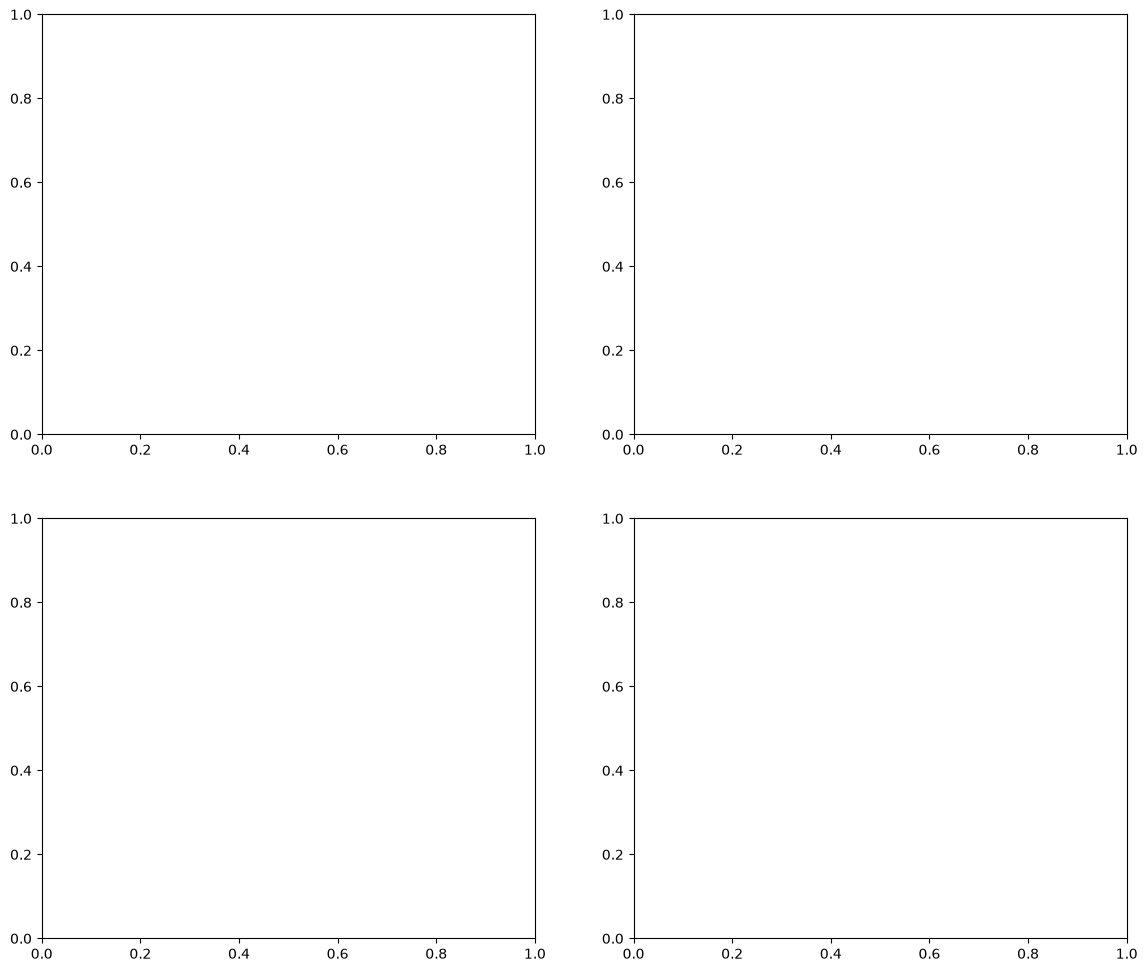

In [2]:
# Step 7 — Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cmap = plt.cm.get_cmap('tab10', n_subtypes)

# Panel A: Scree plot
ax = axes[0, 0]
ax.bar(range(1, 21), pca_scratch.explained_variance_ratio_[:20],
         color='steelblue', edgecolor='black', alpha=0.8)
cumvar = np.cumsum(pca_scratch.explained_variance_ratio_)
ax2 = ax.twinx()
ax2.plot(range(1, 21), cumvar[:20], 'tomato', marker='o', ms=3, lw=2)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained', color='steelblue')
ax2.set_ylabel('Cumulative variance', color='tomato')
ax.set_title('A. Scree plot\n(bars=individual, line=cumulative)')
ax.set_xticks(range(1, 21, 2))

# Panel B: PCA plot (PC1 vs PC2), colored by subtype
ax = axes[0, 1]
for st in range(n_subtypes):
    mask = y_subtype == st
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=[cmap(st)], s=15,
                 alpha=0.7, label=f'Subtype {st}')
ax.set_xlabel(f'PC1 ({pca_scratch.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_scratch.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('B. PCA (PC1 vs PC2)\ncolored by subtype')
ax.legend(fontsize=8)

# Panel C: UMAP colored by subtype
ax = axes[1, 0]
for st in range(n_subtypes):
    mask = y_subtype == st
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1], c=[cmap(st)], s=15,
                 alpha=0.7, label=f'Subtype {st}')
method = 'UMAP' if umap_available else 't-SNE'
ax.set_title(f'C. {method} (top 20 PCs)\ncolored by subtype')
ax.set_xlabel(f'{method}1'); ax.set_ylabel(f'{method}2')
ax.legend(fontsize=8)

# Panel D: Reconstruction error vs. n_components
ax = axes[1, 1]
ks, errs = zip(*reconstruction_errors)
ax.plot(ks, errs, 'steelblue', marker='o', lw=2, ms=5)
ax.set_xlabel('Number of PCs retained')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('D. Reconstruction error\n(diminishing returns after ~50 PCs)')
ax.set_xscale('log')

plt.suptitle('Module 13 NB11: Dimensionality Reduction — PCA and UMAP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dimensionality_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Exercises

1. Implement PCA using the eigendecomposition of the covariance matrix
   (`np.linalg.eigh`). Verify it gives the same loadings as the SVD approach.
2. The batch variable splits samples into two groups. Does it appear as a PC?
   Use a color-coded PCA plot (color by batch) to check.
3. Show the effect of standardization: run PCA without standardizing the RNA-seq
   data. Which features dominate PC1?
4. Vary UMAP `n_neighbors` from 5 to 50. How does the visualization change?
   Which setting better reveals local cluster structure vs. global layout?

---
## Step 10 — Quiz

1. What does the first principal component represent geometrically?
2. Write the SVD of a centered matrix $\tilde{X}$. What are U, S, V?
3. Why must you standardize features before PCA in most cases?
4. What does the `n_neighbors` parameter in UMAP control?
5. Can cluster distances in a UMAP plot be interpreted? Why or why not?

---
## Step 12 — Reflection

> *[In one paragraph: explain why PCA is a linear method and UMAP is non-linear,
> and describe a biological dataset where PCA would fail to separate groups that
> UMAP successfully separates.]*

---
*Next: `12_feature_selection_and_engineering.ipynb`*